# CVD screening model v4 — NHANES 2021–2023

This notebook rebuilds the cardiovascular-disease (CVD) model from the public **NHANES 2021–2023**
survey and evaluates it honestly. It replaces the earlier notebook, which used a small
pre-cleaned subset (536 train / 134 test rows) and tuned its decision threshold on the test set.

**Label.** `CVD = 1` when a doctor ever told the participant they had congestive heart failure,
coronary heart disease, angina, a heart attack or a stroke (NHANES `MCQ160B`–`MCQ160F`).
This is *existing, diagnosed* disease, measured at the same time as the inputs (cross-sectional).

**Evaluation rules used here**
1. A stratified 80 / 20 train–test split; the test set is used **once**, at the end.
2. Model choice, hyper-parameters and the decision threshold come from 5-fold cross-validation on
   the training set only.
3. Accuracy alone is misleading at 12.5 % prevalence (predicting "no CVD" for everyone scores
   87.5 %), so we report ROC AUC, sensitivity, specificity and balanced accuracy.

The feature code lives in `Back-End/ml/nhanes.py` and is imported here, so the API computes
features with exactly the same code that trained the model.

In [1]:
import json, os, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

warnings.filterwarnings("ignore")
BACKEND = Path.cwd().parent if Path.cwd().name == "model" else Path.cwd()
sys.path.insert(0, str(BACKEND))
from ml._native import import_lightgbm
from ml.nhanes import FEATURE_COLUMNS, LABELS, RAW_CODED_COLUMNS, RAW_COLUMNS, RAW_NUMERIC_COLUMNS, build_dataset, build_pipeline

lgb = import_lightgbm()
SEED = 42
MODEL_DIR = BACKEND / "model"
CACHE = Path(os.environ.get("NHANES_CACHE", MODEL_DIR / "nhanes_cache"))
np.random.seed(SEED)
print("sklearn", sklearn.__version__, "| lightgbm", lgb.__version__)

sklearn 1.6.1 | lightgbm 4.6.0


## 1. Build the dataset from NHANES

In [2]:
data = build_dataset(CACHE)  # downloads the .xpt tables from the CDC on first run, then reads the cache
data.to_csv(MODEL_DIR / "nhanes_cvd_2021_2023.csv", index=False)
X, y = data[RAW_COLUMNS], data["CVD"].to_numpy()
print(f"{len(data)} adults, {y.sum()} with CVD ({y.mean():.1%})")
age_groups = pd.cut(data.RIDAGEYR, [17, 30, 40, 50, 60, 70, 80])
display(pd.DataFrame({"patients": data.groupby(age_groups, observed=True).size(),
                      "CVD rate": data.groupby(age_groups, observed=True).CVD.mean().round(3)}))
display(X.isna().mean().sort_values(ascending=False).head(8).round(3).rename("missing share"))

5330 adults, 665 with CVD (12.5%)


,patients,CVD rate
RIDAGEYR,,
"(17, 30]",619,0.006
"(30, 40]",797,0.013
"(40, 50]",688,0.041
"(50, 60]",917,0.126
"(60, 70]",1307,0.174
"(70, 80]",1002,0.279


BPQ150      0.624
SMQ040      0.590
INDFMPIR    0.127
BMXWAIST    0.030
URDACT      0.013
LBXSCR      0.010
LBXSUA      0.010
SLD012      0.010
Name: missing share, dtype: float64

## 2. Train / test split

The test set (20 %) is put aside now and only used in section 6.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
print(f"train {len(y_train)} ({y_train.sum()} CVD) | test {len(y_test)} ({y_test.sum()} CVD)")

train 4264 (532 CVD) | test 1066 (133 CVD)


## 3. Model comparison (5-fold cross-validation on the training set)

All candidates share the same features, imputation and scaling (`ml.nhanes.build_pipeline`).
Class weights balance the 12.5 % prevalence.

In [4]:
def lightgbm():
    return lgb.LGBMClassifier(n_estimators=400, learning_rate=0.02, num_leaves=15, min_child_samples=30,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2,
                              is_unbalance=True, verbosity=-1, random_state=SEED)

candidates = {
    "Logistic regression (C=0.01)": LogisticRegression(C=0.01, max_iter=5000, class_weight="balanced"),
    "Logistic regression (C=0.1)": LogisticRegression(C=0.1, max_iter=5000, class_weight="balanced"),
    "Logistic regression (C=1)": LogisticRegression(C=1, max_iter=5000, class_weight="balanced"),
    "LightGBM": lightgbm(),
    "Random forest": RandomForestClassifier(400, min_samples_leaf=5, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "Stack (LR + LightGBM + RF)": StackingClassifier(
        [("lr", LogisticRegression(C=0.01, max_iter=5000, class_weight="balanced")), ("lgbm", lightgbm()),
         ("rf", RandomForestClassifier(400, min_samples_leaf=5, class_weight="balanced", n_jobs=-1, random_state=SEED))],
        final_estimator=LogisticRegression(), cv=5, n_jobs=1),
}
rows, oof = [], {}
for name, model in candidates.items():
    fold_auc = []
    pred = np.zeros(len(y_train))
    for tr, va in cv.split(X_train, y_train):
        fitted = build_pipeline(model).fit(X_train.iloc[tr], y_train[tr])
        pred[va] = fitted.predict_proba(X_train.iloc[va])[:, 1]
        fold_auc.append(roc_auc_score(y_train[va], pred[va]))
    oof[name] = pred
    rows.append({"model": name, "CV AUC (mean)": np.mean(fold_auc), "fold min": np.min(fold_auc), "fold max": np.max(fold_auc)})
comparison = pd.DataFrame(rows).set_index("model").round(3)
display(comparison)

,CV AUC (mean),fold min,fold max
model,,,
Logistic regression (C=0.01),0.873,0.846,0.889
Logistic regression (C=0.1),0.869,0.839,0.885
Logistic regression (C=1),0.867,0.838,0.884
LightGBM,0.866,0.831,0.889
Random forest,0.865,0.838,0.882
Stack (LR + LightGBM + RF),0.875,0.847,0.893


**Selection rule:** take the simplest model whose CV AUC is within 0.005 of the best. Logistic
regression is preferred when it ties: it is explainable, fast and its coefficients can be
inspected for clinical sense (section 7).

In [5]:
best = comparison["CV AUC (mean)"].max()
order = list(candidates)  # listed from simplest to most complex
chosen = next(n for n in order if comparison.loc[n, "CV AUC (mean)"] >= best - 0.005)
print("best CV AUC", best, "-> chosen:", chosen)

best CV AUC 0.875 -> chosen: Logistic regression (C=0.01)


## 4. Decision threshold from out-of-fold predictions (training set only)

Youden's J (sensitivity + specificity − 1) on the out-of-fold scores. The test set is not used.

In [6]:
fpr, tpr, thr = roc_curve(y_train, oof[chosen])
threshold = float(thr[np.argmax(tpr - fpr)])
oof_pred = oof[chosen] >= threshold
print(f"threshold {threshold:.4f} | CV sensitivity {oof_pred[y_train == 1].mean():.3f} | CV specificity {(~oof_pred[y_train == 0]).mean():.3f}")

threshold 0.4729 | CV sensitivity 0.829 | CV specificity 0.771


## 5. Fit the final model on the whole training set

In [7]:
final = build_pipeline(candidates[chosen]).fit(X_train, y_train)

## 6. One-time evaluation on the held-out test set

In [8]:
prob = final.predict_proba(X_test)[:, 1]
pred = prob >= threshold
tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
sens, spec = tp / (tp + fn), tn / (tn + fp)

rng = np.random.default_rng(SEED)
pos, neg = np.where(y_test == 1)[0], np.where(y_test == 0)[0]
boot = [roc_auc_score(y_test[i], prob[i]) for i in
        (np.concatenate([rng.choice(pos, len(pos)), rng.choice(neg, len(neg))]) for _ in range(1000))]

metrics = {
    "model_name": "CVD NHANES Logistic" if "Logistic" in chosen else "CVD NHANES " + chosen,
    "model_version": "4.0.0",
    "algorithm": chosen,
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "data": "NHANES 2021-2023, adults 18+ with measured BP and cholesterol",
    "label": "Doctor-diagnosed CHF, CHD, angina, heart attack or stroke (MCQ160B-F)",
    "n_train": int(len(y_train)), "n_test": int(len(y_test)),
    "prevalence": float(y.mean()),
    "decision_threshold": threshold,
    "auc": float(roc_auc_score(y_test, prob)),
    "auc_ci95": [float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))],
    "cv_auc": float(comparison.loc[chosen, "CV AUC (mean)"]),
    "sensitivity": float(sens), "recall": float(sens), "specificity": float(spec),
    "balanced_accuracy": float((sens + spec) / 2),
    "precision": float(tp / (tp + fp)),
    "accuracy": float((tp + tn) / len(y_test)),
    "f1": float(2 * tp / (2 * tp + fp + fn)),
    "pr_auc": float(average_precision_score(y_test, prob)),
    "brier": float(brier_score_loss(y_test, prob)),
    "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    "note": ("Cross-sectional label (existing diagnosed CVD). Class-weighted training: scores are not "
             "calibrated probabilities. Accuracy is at 12.5% prevalence; see balanced_accuracy."),
}
display(pd.Series({k: metrics[k] for k in ["auc", "auc_ci95", "cv_auc", "sensitivity", "specificity",
                                            "balanced_accuracy", "precision", "accuracy", "pr_auc"]}))

auc                                                  0.863614
auc_ci95             [0.8322317046635883, 0.8923927584233896]
cv_auc                                                  0.873
sensitivity                                          0.842105
specificity                                          0.733119
balanced_accuracy                                    0.787612
precision                                            0.310249
accuracy                                             0.746717
pr_auc                                               0.479359
dtype: object

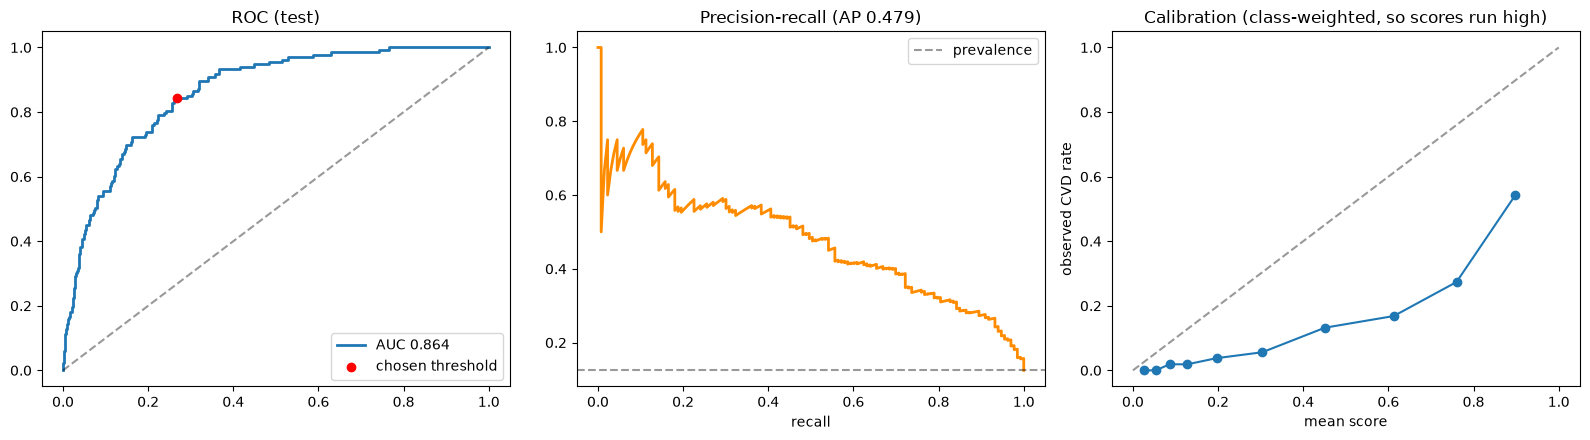

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
f, t, _ = roc_curve(y_test, prob)
ax[0].plot(f, t, lw=2, label=f"AUC {metrics['auc']:.3f}"); ax[0].plot([0, 1], [0, 1], "k--", alpha=.4)
ax[0].scatter([1 - spec], [sens], c="red", zorder=3, label="chosen threshold"); ax[0].set_title("ROC (test)"); ax[0].legend()
p, r, _ = precision_recall_curve(y_test, prob)
ax[1].plot(r, p, lw=2, color="darkorange"); ax[1].axhline(y_test.mean(), ls="--", c="k", alpha=.4, label="prevalence")
ax[1].set_title(f"Precision-recall (AP {metrics['pr_auc']:.3f})"); ax[1].set_xlabel("recall"); ax[1].legend()
obs, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
ax[2].plot(mean_pred, obs, "o-"); ax[2].plot([0, 1], [0, 1], "k--", alpha=.4)
ax[2].set_title("Calibration (class-weighted, so scores run high)"); ax[2].set_xlabel("mean score"); ax[2].set_ylabel("observed CVD rate")
plt.tight_layout(); plt.savefig(MODEL_DIR / "ml_full_train_diagnostic.png", dpi=150); plt.show()

## 7. Why the model cannot learn "higher readings → higher risk"

The label is *already-diagnosed* CVD. Once diagnosed, patients are treated: statins lower their
cholesterol and BP medicines lower their blood pressure. A cross-sectional model therefore sees
people **with** CVD carrying **lower** measured cholesterol. The coefficients and the comparison
below show it.

In [10]:
model = final.named_steps["model"]
if hasattr(model, "coef_"):
    names = list(FEATURE_COLUMNS) + [f"missing_{FEATURE_COLUMNS[i]}" for i in final.named_steps["impute"].indicator_.features_]
    coef = pd.Series(model.coef_[0], index=names).sort_values(key=abs, ascending=False)
    display(coef.head(15).round(3).rename("standardised coefficient"))
treated = data.assign(statin=data.BPQ101D.eq(1))
display(treated.groupby(["CVD", "statin"]).LBXTC.agg(["count", "mean"]).round(1)
        .rename(columns={"count": "patients", "mean": "mean total cholesterol"}))

age              0.602
gen_health       0.504
chol_meds        0.298
smoker_ever      0.250
high_bp_hx       0.244
egfr            -0.193
high_chol_hx     0.165
total_chol      -0.156
male             0.145
hdl             -0.143
sleep_weekday    0.123
non_hdl         -0.110
log_uacr         0.106
education       -0.102
rdw              0.101
Name: standardised coefficient, dtype: float64

patients  mean total cholesterol
CVD statin                                  
0   False       3585                   196.0
    True        1080                   176.4
1   False        208                   184.4
    True         457                   159.3

In [11]:
base = X_train.median(numeric_only=True)
probe = pd.DataFrame([base] * 4)
for c in RAW_CODED_COLUMNS: probe[c] = X_train[c].mode().iloc[0]
probe["RIDAGEYR"] = [21, 21, 65, 65]
probe["BPXOSY1"], probe["BPXODI1"], probe["LBXTC"] = [190, 118, 190, 118], [110, 75, 110, 75], [300, 170, 300, 170]
probe["score"] = final.predict_proba(probe[RAW_COLUMNS])[:, 1].round(3)
display(probe[["RIDAGEYR", "BPXOSY1", "BPXODI1", "LBXTC", "score"]])

,RIDAGEYR,BPXOSY1,BPXODI1,LBXTC,score
0,21,190,110,300,0.019
1,21,118,75,170,0.052
2,65,190,110,300,0.101
3,65,118,75,170,0.247


High BP and cholesterol do **not** raise this score, and can lower it. This is why the app pairs the
model with (a) guideline clinical alerts and (b) the AHA PREVENT equations, which were built from
long-term follow-up studies and correctly raise 10-year risk with higher BP and cholesterol.
This model is best read as "how closely the profile resembles people living with diagnosed CVD".

## 8. Would more data help? (learning curve, cross-validated)

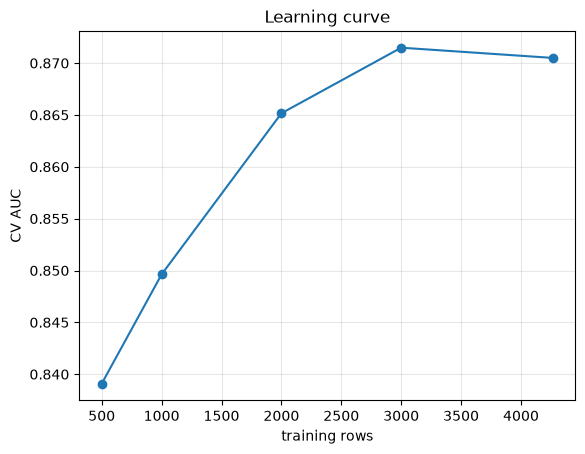

{500: np.float64(0.839), 1000: np.float64(0.85), 2000: np.float64(0.865), 3000: np.float64(0.871), 4264: np.float64(0.87)}


In [12]:
sizes, curve = [500, 1000, 2000, 3000, len(y_train)], []
for n in sizes:
    aucs = []
    for seed in range(5):
        idx = np.random.default_rng(seed).choice(len(y_train), n, replace=False) if n < len(y_train) else np.arange(n)
        p = cross_val_predict(build_pipeline(candidates[chosen]), X_train.iloc[idx], y_train[idx],
                              cv=StratifiedKFold(5, shuffle=True, random_state=seed), method="predict_proba")[:, 1]
        aucs.append(roc_auc_score(y_train[idx], p))
    curve.append(np.mean(aucs))
plt.plot(sizes, curve, "o-"); plt.xlabel("training rows"); plt.ylabel("CV AUC"); plt.title("Learning curve"); plt.grid(alpha=.3); plt.show()
print(dict(zip(sizes, np.round(curve, 3))))

The curve flattens: more rows of the same survey add little. The ceiling comes from the label and
the cross-sectional design, not from the algorithm. Reaching 90 % honest accuracy would need
longitudinal outcome data (who goes on to have an event), not more of the same snapshot.

## 9. Feature importance and exported artifacts

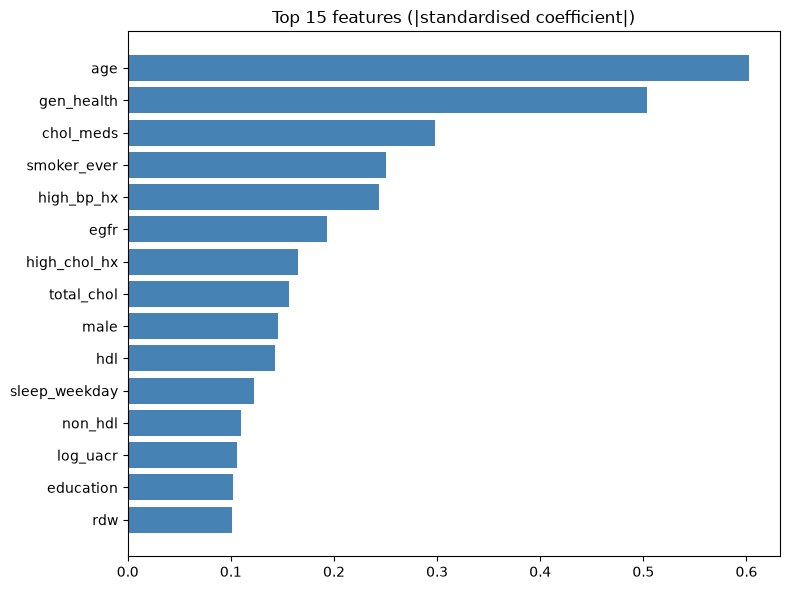

saved: cvd_pipeline.joblib, feature_importance.png, feature_schema.json, meta_learner.joblib, metrics_ml.json, ml_full_train_diagnostic.png, model_lgbm.joblib, model_lr.joblib, model_rf.joblib, model_xgb.joblib, nhanes_cvd_2021_2023.csv, preprocessor_ml.joblib, testdata.csv, traindata.csv


In [13]:
if hasattr(model, "coef_"):
    top = coef.drop([n for n in coef.index if n.startswith("missing_")]).abs().sort_values().tail(15)
    plt.figure(figsize=(8, 6)); plt.barh([LABELS.get(n, n) for n in top.index], top.values, color="steelblue")
    plt.title("Top 15 features (|standardised coefficient|)"); plt.tight_layout()
    plt.savefig(MODEL_DIR / "feature_importance.png", dpi=150); plt.show()

reference = {c: float(X_train[c].median()) for c in RAW_NUMERIC_COLUMNS}
reference.update({c: float(X_train[c].mode().iloc[0]) for c in RAW_CODED_COLUMNS})
schema = {
    "model_name": metrics["model_name"], "model_version": metrics["model_version"],
    "raw_columns": RAW_COLUMNS, "numeric_columns": RAW_NUMERIC_COLUMNS, "coded_columns": RAW_CODED_COLUMNS,
    "reference_values": {k: round(v, 4) for k, v in reference.items()},
    "labels": {c: LABELS[c] for c in RAW_COLUMNS}, "decision_threshold": threshold,
}
joblib.dump(final, MODEL_DIR / "cvd_pipeline.joblib", compress=3)
(MODEL_DIR / "feature_schema.json").write_text(json.dumps(schema, indent=2) + "\n")
(MODEL_DIR / "metrics_ml.json").write_text(json.dumps(metrics, indent=2) + "\n")
print("saved:", ", ".join(p.name for p in sorted(MODEL_DIR.glob("*")) if p.suffix in {".joblib", ".json", ".png", ".csv"}))